# 월드컵 예측하기

---
## 0. `print` 사용해보기

`print를 직접 작성해봤어요!`  
`오늘의 목표 : 월드컵 승부 예측하기`  

In [ ]:
print("print를 직접 작성해봤어요!")
print("오늘의 목표 : 월드컵 승부 예측하기")

print를 직접 작성해봤어요!
오늘의 목표 : 월드컵 승부 예측하기


---
## 1. 필수 기초
월드컵 예측을 위한 최소 기초 개념 다지기

### 1-1. 값에 이름 붙이기

In [ ]:
my_team = 'South Korea'
print(my_team)

goal = 3
print(goal)

South Korea
3


### 1-2. 계산기처럼 사용해보기

In [ ]:
print(goal + 1)

print(goal * 2)

print(goal / 4)
print(10 / 4)

4
6
0.75
2.5


### 1-3. 값을 여러 개 담기

In [ ]:
worldcup_teams = ['South Korea', 'USA', 'Brazil', 'Argentina', 'France', 'England', 'Spain']

print(worldcup_teams) # 배열 출력

print(worldcup_teams[3]) # 배열 인덱스에 저장된 값 지정 출력

print(len(worldcup_teams)) # 길이 출력 len() 함수

['South Korea', 'USA', 'Brazil', 'Argentina', 'France', 'England', 'Spain']
Argentina
7


### 1-4. 문장 안에 값을 끼워 넣기

`내가 응원하는 팀은 South Korean이고, 오늘 3골을 넣었으면 좋겠어.` 를 `print`로 출력하려면!

In [18]:
favorite_team = []
for team in worldcup_teams:
  if team == 'South Korea':
    favorite_team.append(team)

print(f"내가 응원하는 팀은 {my_team}이고, 오늘 {goal}골을 넣었으면 좋겠어.")

내가 응원하는 팀은 ['South Korea']이고, 오늘 3골을 넣었으면 좋겠어.


---
## 2. 데이터 불러오기

`pandas` 라이브러리 사용  
`pandas`는 엑셀같은 표 데이터를 코드로 다루는 도구  
보통 `pandas`로 불러온 데이터는 `df`라고 부름(DataFrame)  

### 2-1. 라이브러리 설치

In [19]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [22]:
# pandas 라이브러리 불러오기
import pandas as pd

In [23]:
!git clone https://github.com/martj42/international_results.git

Cloning into 'international_results'...
remote: Enumerating objects: 1148, done.
remote: Counting objects: 100% (579/579), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 1148 (delta 557), reused 554 (delta 547), pack-reused 569 (from 1)
Receiving objects: 100% (1148/1148), 3.66 MiB | 11.98 MiB/s, done.
Resolving deltas: 100% (696/696), done.


In [25]:
# df 변수에 타겟 파일 저장
df = pd.read_csv('international_results/results.csv')

In [29]:
# df가 잘 불러와졌는지 확인하기 위해 미리보기 기능
df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### 2-2. 데이터셋 정리
- `date` : 경기 날짜
- `home_team`: 홈 팀
- `away_team` : 어웨이 팀
- `home_score` / `away_score` : 각 팀 득점
- `tournament` : 경기 이름
- `city` / `country`  : 개최 장소
- `neutral` : 중립 지역(홈팀도 어웨이 팀도 아닌 지역)에서 경기 열림

### 2-3. 데이터 크기 확인

In [38]:
# shape 함수
df.shape

# 행(경기 수), 열(항목 수) (49505, 9)

(49505, 9)

In [44]:
print(f"행(경기 수), 열(항목 수) {df.shape}")

print("(행, 열)", df.shape) # 여러 개의 데이터를 출력할 때, "쉼표"로 구분할 수 있다!

행(경기 수), 열(항목 수) (49505, 9)
(행, 열) (49505, 9)


### 2-4. 월드컵 경기만 골라내기

`tournament` 열이 `"FIFA World Cup"`인 행만 남기기 = *필터링*

In [48]:
wc = df[df['tournament'] == 'FIFA World Cup']
print(f"월드컵 경기 수: {len(wc)}")

월드컵 경기 수: 1064


In [49]:
wc.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True


In [56]:
korea_wc = [name for name in wc['home_team'].unique() if 'Korea' in str(name)]
print(korea_wc)

['South Korea', 'North Korea']


### 2-5. 우리나라 월드컵 경기 필터링

우리나라는 홈팀일 수도, 원정팀일 수도 있다!
`home_team` 아니면 `away_team`을 합쳐서 출력해야겠찌?

In [59]:
Kor_Match = wc[(wc['home_team'] == 'South Korea') | (wc['away_team'] == 'South Korea')]

print("한국 월드컵 경기 수", len(Kor_Match))

한국 월드컵 경기 수 41


In [63]:
Kor_Match[["date", "home_team", 'away_team', 'home_score','away_score']].tail(10)

,date,home_team,away_team,home_score,away_score
41650,2018-06-18,Sweden,South Korea,1.0,0.0
41666,2018-06-23,South Korea,Mexico,1.0,2.0
41679,2018-06-27,South Korea,Germany,2.0,0.0
45731,2022-11-24,Uruguay,South Korea,0.0,0.0
45747,2022-11-28,South Korea,Ghana,2.0,3.0
45764,2022-12-02,South Korea,Portugal,2.0,1.0
45770,2022-12-05,Brazil,South Korea,4.0,1.0
49406,2026-06-11,South Korea,Czech Republic,2.0,1.0
49430,2026-06-18,Mexico,South Korea,1.0,0.0
49454,2026-06-24,South Africa,South Korea,1.0,0.0


## 4. 응용

### 4-1. 월드컵 역사상 가장 골이 가장 많이 터진 경기는?

In [64]:
wc_1st = wc.copy()

In [65]:
wc_1st.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True


In [68]:
wc_1st["total_goals"] = wc_1st["home_score"] + wc_1st["away_score"] # 이렇게 하면 열이 추가가 된다!

In [71]:
top = wc_1st.sort_values("total_goals", ascending = False ).iloc[0] # ascending: 오름차순으로 정렬하라(최고 수치를 보기 위해 False)

print(top)

date               1954-06-26
home_team         Switzerland
away_team             Austria
home_score                5.0
away_score                7.0
tournament     FIFA World Cup
city                 Lausanne
country           Switzerland
neutral                 False
total_goals              12.0
Name: 3975, dtype: object


In [79]:
wc_2nd = wc.copy()

wc_2nd["total_goals"] = wc_2nd["home_score"] = wc_2nd["away_score"]

top2 = wc_2nd.sort_values("total_goals", ascending = False).iloc[0]

print(top2)

date               1938-06-12
home_team                Cuba
away_team              Sweden
home_score                8.0
away_score                8.0
tournament     FIFA World Cup
city                  Antibes
country                France
neutral                  True
total_goals               8.0
Name: 2340, dtype: object


In [82]:
### 4-2. 월드컵 최다 득점 국가 top 10

home_goals = wc.groupby("home_team")["home_score"].sum() # 홈에서 넣은 골 합계
away_goals = wc.groupby("away_team")["away_score"].sum()

home_goals.head(5)
away_goals.head(5)

total_goals = home_goals.add(away_goals, fill_value=0)

goals_sort = total_goals.sort_values(ascending = False)

In [83]:
goals_sort.head(10)

,0
Brazil,247.0
Germany,243.0
Argentina,166.0
France,152.0
Italy,128.0
Spain,119.0
England,115.0
Netherlands,107.0
Uruguay,92.0
Hungary,87.0


In [89]:
import matplotlib.pyplot as plt

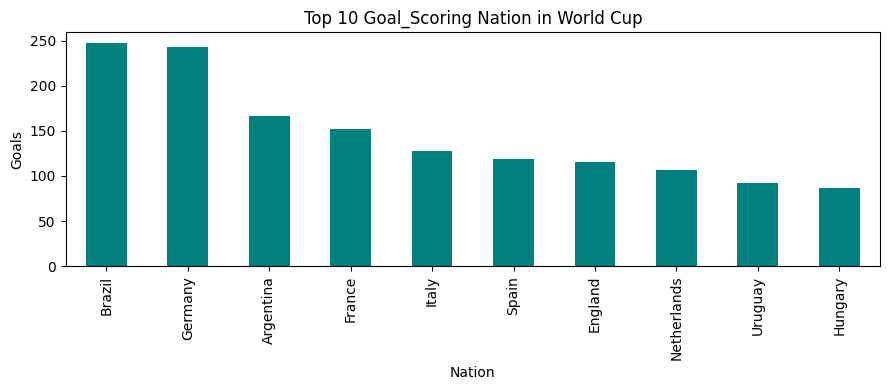

In [92]:
top10 = goals_sort.head(10)

plt.figure(figsize=(9,4))
top10.plot(kind='bar', color="teal")
plt.title("Top 10 Goal_Scoring Nation in World Cup")
plt.xlabel("Nation")
plt.ylabel("Goals")
plt.tight_layout() # 여백 자동 정리
plt.show() # 보여주기

승률, 평균 득점을 가지고 누가 이길 것인지를 예측하기

## 5. 간단한 승부 예측해보기!

### 5-1. 팀 성적을 계산하는 "도구" 만들기

`def`를 사용하여 `팀 이름을 입력하면 성적을 출력하는 도구` 만들기

In [103]:
def team_state(team):
  home = df[df["home_team"] == team] # team이 home이라면?
  away = df[df["away_team"] == team] # team이 away라면?
  wins = (home["home_score"] > home["away_score"]).sum() + (away["home_score"] < away["away_score"]).sum() # 승리했던 내용 다 합산해야 함
  games = len(home) + len(away) # 모든 경기 수를 가져오자
  goal_for = home["home_score"].sum() + away["away_score"].sum() # 모든 골 수: 이긴 건 상관 없음

  return {
      "games": int(games),
      "win_rate": round(float(wins / games), 3),
      "avg_goals": round(float(goal_for / games), 2)
  }

In [106]:
team_state("Brazil")

{'games': 1064, 'win_rate': 0.634, 'avg_goals': 2.18}

In [107]:
team_state("South Korea")

{'games': 1010, 'win_rate': 0.534, 'avg_goals': 1.78}

### 5-2. 두 팀을 비교해 승자 예측하기

In [110]:
def predict(team_a, team_b):
  a = team_state(team_a)
  b = team_state(team_b)

  # 두 팀의 성적을 비교해서 a가 이길 대략적인 확률 계산
  prob_a = a["win_rate"] / (a["win_rate"] + b["win_rate"])
  prob_b = b["win_rate"] / (a["win_rate"] + b["win_rate"])

  winner = team_a if prob_a > 0.5 else team_b
  edge = round(max(prob_a, prob_b) * 100) # max란? 값을 2개를 보낼 때면, 둘 중에 더 큰 값을 반환한다.

  print(f"{team_a}: 승률: {a["win_rate"]}, 평균 득점: {a["avg_goals"]}골")
  print(f"{team_b}: 승률: {b["win_rate"]}, 평균 득점: {b["avg_goals"]}골")
  print(f"-> 예측 승자: {winner} 약 {edge}% 우세")

In [111]:
predict("Brazil", "France")

Brazil: 승률: 0.634, 평균 득점: 2.18골
France: 승률: 0.513, 평균 득점: 1.84골
-> 예측 승자: Brazil 약 55% 우세


### 5-3. 승리 예측해보기

2026.07.12 아르헨티나 VS 스위스 승리 예측

In [112]:
predict("Argentina", "Switzerland")

Argentina: 승률: 0.555, 평균 득점: 1.9골
Switzerland: 승률: 0.358, 평균 득점: 1.49골
-> 예측 승자: Argentina 약 61% 우세
